# 0. Load Data

## 0.1 Load Data

In [1]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-16-02") 
# run_dir = os.path.join("..", "..", "outputs", "run-25-09-13-18")  # RNA-seq
run_dir = os.path.join("..","..","outputs","run-25-09-17-01")   # Microarray
output_dir = os.path.join(run_dir, "outputs")
com_tsv_path = "/aloy/home/ddalton/databases/HuDiNe/AllNet5.tsv"
embedding_type = "ft"
dpi = 120
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json
with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT

In [2]:
split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

## 0.2 Load Comorbidity Pairs

In [3]:
import ast
# load do graph
do_graph = ut.load_do_graph()

# map doid to term
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# map doid to icd
doid_to_icd = dict()
for node, data in do_graph.nodes(data=True):
    for ref in data.get("xref", []):
        if ref.startswith("ICD9CM:"):
            icd = ref.split(":")[1]
            doid_to_icd[node] = icd

# map icd to doid
icd_to_doid = {v: k for k, v in doid_to_icd.items()}

# load comorbidity pairs
df_com = pd.read_csv(com_tsv_path, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
print(f"Loaded {df_com.shape[0]} comorbidity pairs")

# map comorbidity ICD pairs to DOID
df_com["doid_1"] = df_com["#icd9-1"].map(icd_to_doid)
df_com["doid_2"] = df_com["icd9-2"].map(icd_to_doid)
df_com["name_1"] = df_com["doid_1"].map(doid_to_term)
df_com["name_2"] = df_com["doid_2"].map(doid_to_term)

# drop all rows with NA doid
df_com.dropna(subset=["doid_1", "doid_2"], how="any", inplace=True)
print(f"Mapped to {df_com.shape[0]} comorbidity pairs with DOID")

# filter down to those present in our data
_all_doids = list(adata_train.obs["doid_id"].unique())
df_com = df_com.query("doid_1 in @_all_doids and doid_2 in @_all_doids")
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with DOID present in data")

# create sorted pair column
df_com["pair_sorted"] = df_com.apply(lambda row: str(tuple(sorted([row["doid_1"], row["doid_2"]]))), axis=1)

# fix column formats
df_com["n.common"] = df_com["n.common"].astype(int)
df_com["RR"] = df_com["RR"].astype(float)
df_com["pair_sorted"] = df_com["pair_sorted"].apply(ast.literal_eval)


Loaded 6088553 comorbidity pairs
Mapped to 225744 comorbidity pairs with DOID
Filtered to 961 comorbidity pairs with DOID present in data


In [4]:
_df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")

_df_com_100["pval.adj"] = _df_com_100["pval.adj"].astype(float)

for rr_i in [1, 2, 5, 10]:
    # _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)& (_df_com_100["pval.adj"]<=0.05)]
    _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)]
    print(f"Filtered to {_df_q.shape[0]} comorbidity pairs with RR>{rr_i}")


Filtered to 961 comorbidity pairs with >100 common patients
Filtered to 113 comorbidity pairs with RR>1
Filtered to 31 comorbidity pairs with RR>2
Filtered to 8 comorbidity pairs with RR>5
Filtered to 6 comorbidity pairs with RR>10


/tmp/ipykernel_85664/149838223.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_com_100["pval.adj"] = _df_com_100["pval.adj"].astype(float)


In [5]:
_df_com_100["RR"].astype(float)

475009      1.016025
475020      0.741288
625287      0.958925
625298      1.287068
625305      0.791205
             ...    
5396799    38.529233
5396848     5.253054
5399362    16.014510
5423569    17.510922
5423813     3.511008
Name: RR, Length: 158, dtype: float64

In [6]:
# _df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")


for rr_i in [1, 2, 5, 10]:
    _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)& (_df_com_100["pval.adj"]<2)]
    print(f"Filtered to {_df_q.shape[0]} comorbidity pairs with RR>{rr_i}")


Filtered to 961 comorbidity pairs with >100 common patients
Filtered to 56 comorbidity pairs with RR>1
Filtered to 10 comorbidity pairs with RR>2
Filtered to 0 comorbidity pairs with RR>5
Filtered to 0 comorbidity pairs with RR>10


In [7]:
# Map diseases -> Relative Risk
rr_map = dict()
for _, r in _df_com_100.iterrows():
    d1 = r["doid_1"]
    d2 = r["doid_2"]
    rr = r["RR"]
    if d1 not in rr_map.keys():
        rr_map[d1] = dict()
    if d2 not in rr_map.keys():
        rr_map[d2] = dict()
    rr_map[d1][d2] = rr
    rr_map[d2][d1] = rr



## 0.3 Load Disease Ontology Pairs

In [8]:
"""0.3 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)


df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))


Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (21528, 8)
Nº of significant pairs in dataset (top 5% IC): (2559, 8)
Nº of significant pairs in dataset (top 1% IC): (920, 8)
Nº of negative pairs in dataset (outside 5%): (18969, 8)


In [9]:
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

In [10]:
_do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")

# map disease disease -> lin
dis_2_lin = dict()
for _,r in _do_df_ic_query.iterrows():
    d1 = r["do1"]
    d2 = r["do2"]
    lin = r["lin"]
    if d1 not in dis_2_lin.keys():
        dis_2_lin[d1] = dict()
    if d2 not in dis_2_lin.keys():
        dis_2_lin[d2] = dict()
    
    dis_2_lin[d1][d2] = lin
    dis_2_lin[d2][d1] = lin

In [11]:
# get for each pair LIN similarity
_lin_vals = list()
for _,r in _df_com_100.iterrows():
    d1 = r["doid_1"]
    d2 = r["doid_2"]
    lin = dis_2_lin[d1][d2]
    _lin_vals.append(lin)

_df_com_100 = _df_com_100.copy()
_df_com_100["lin"] = _lin_vals

# 1. Compute Similarity


In [12]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable


# functions

# 2. Load Data

# load embeddings
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

elif embedding_type == "raw":
    embeddings_test = adata_test.X
    embeddings_valid = adata_valid.X
    embeddings_train = adata_train.X

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

elif embedding_type == "raw_normed":
    embeddings_test = adata_test.layers["X_normed"]
    embeddings_valid = adata_valid.layers["X_normed"]
    embeddings_train = adata_train.layers["X_normed"]

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)


# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

# compute cosine similarity between sets
c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "cosine")
c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, "cosine")



# 2. Benchmark Comorbidities

## 2.1 Benchmark All Comorbidities

In [13]:
# imports 
from matplotlib.ticker import EngFormatter
import random
import importlib
importlib.reload(vz)

# variables
_bin_labels = ["'1-1.5 RR'","'1.5-2 RR'","'2-5 RR'","'5-10 RR'","'10+ RR'"]
n_samples = 20000
purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]


# functions
def get_bins(vals):
    labels = []
    for v in vals:
        if 1 <= v < 1.5:
            lab = "1-1.5 RR"
        elif 1.5 <= v < 2:
            lab = "1.5-2 RR"
        elif 2 <= v < 5:
            lab = "2-5 RR"
        elif 5 <= v < 10:
            lab = "5-10 RR"
        elif v >= 10:
            lab = "10+ RR"
        else:
            lab = 0  # or None, depending on what you prefer
        labels.append(lab)
    return labels


def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    pos = np.array(pos)
    neg = np.array(neg)
    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc


def get_auroc_df(split_name:str, s_comorbid:List, s_unr:np.array, ndigits:int=3) -> pd.DataFrame:
    return pd.DataFrame({
        "Split": [split_name],
        "1-1.5 RR": [round(_auroc(s_comorbid[0], s_unr),ndigits=ndigits)],
        "1.5-2 RR": [round(_auroc(s_comorbid[1], s_unr),ndigits=ndigits)],
        "2-5 RR ": [round(_auroc(s_comorbid[2], s_unr),ndigits=ndigits)],
        "+10 RR" : [round(_auroc(s_comorbid[3], s_unr),ndigits=ndigits)],
    })


# define related and unrelated dataframes
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# get similarity of unrelated diseases
ts_s_unr =vz.get_unrelated_pairs_split(df_test, df_train, df_related, c_matrix_test_vs_train, n_samples=n_samples, use_ctrl=True, exclude_dts=False)
vl_s_unr = vz.get_unrelated_pairs_split(df_valid, df_train, df_related, c_matrix_valid_vs_train, n_samples=n_samples, use_ctrl=True, exclude_dts=False)
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=n_samples,
    seed=42,
)

# bin data based on similarity
_df_com_100 = _df_com_100.copy()
_df_com_100["shortest_path_length"] = get_bins(_df_com_100["RR"].values)


# train
tr_s_all, tr_w_all, tr_l_all = vz.get_related_dis_sim(
    adata_train, c_matrix_train, _df_com_100, df_unrelated, labels=_bin_labels, sample=n_samples,
)

# valid
vl_s_all, vl_w_all, vl_l_all = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train, _df_com_100, df_unrelated, labels=_bin_labels, sample=n_samples)

# test
ts_s_all, ts_w_all, ts_l_all = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train, _df_com_100, df_unrelated, labels=_bin_labels, sample=n_samples)


  0%|          | 0/21736 [00:00<?, ?it/s]

100%|██████████| 21736/21736 [00:50<00:00, 430.37it/s]


182805782 unrelated pairs found
20000
Selected 20000 unrelated pairs
Sampled pairs: 20000


100%|██████████| 21736/21736 [00:47<00:00, 453.85it/s]


83340211 unrelated pairs found
20000
Selected 20000 unrelated pairs
Sampled pairs: 20000
209 diseases in dataset


...

Nº of related disease pairs for '5-10 RR': 152850
[SP '10+ RR'] Nº of related disease pairs: 6


100%|██████████| 6/6 [00:00<00:00, 53.77it/s]


Nº of related disease pairs for '10+ RR': 90450
Nº of diseases: 206


100%|██████████| 206/206 [00:01<00:00, 107.58it/s]


Nº of unrelated disease pairs: 1129332


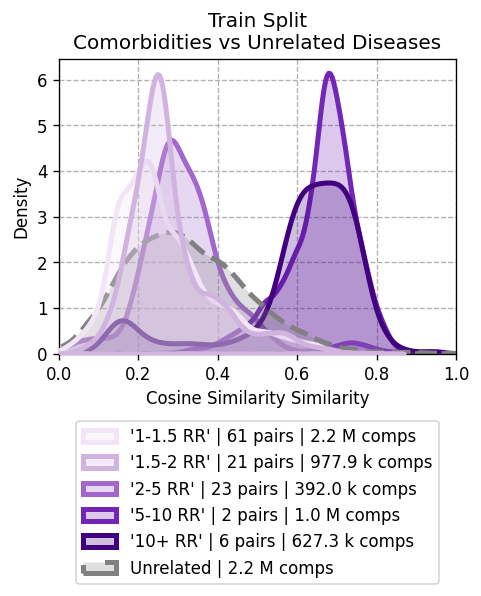

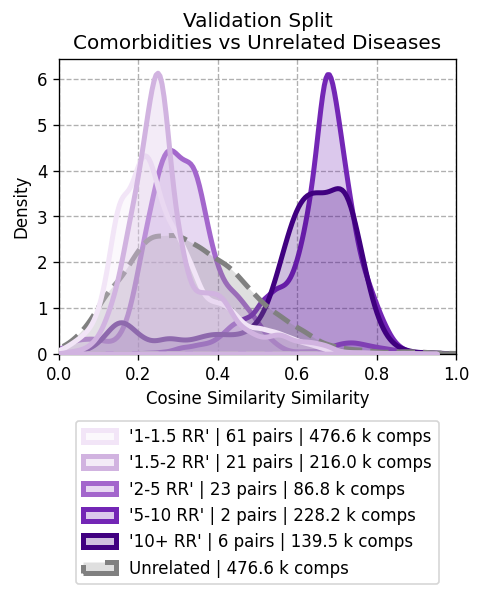

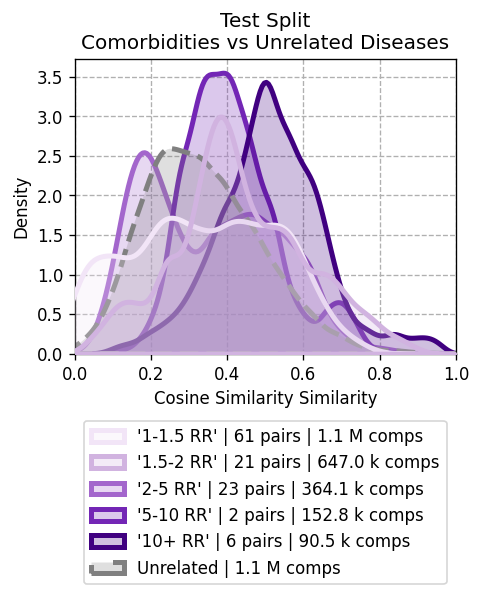

In [14]:
# plot distributions
vz.plot_kde(tr_s_all[:-2] + [tr_s_unr], 
            labels=tr_l_all[:-2] + [tr_l_all[-1]]   ,
            title="Train Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = n_samples,   
            metric="Cosine Similarity",
            dpi=dpi)

vz.plot_kde(vl_s_all[:-2] + [vl_s_unr], 
            labels=vl_l_all[:-2] + [vl_l_all[-1]]   ,
            title="Validation Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = n_samples,   
            metric="Cosine Similarity",
            dpi=dpi)

vz.plot_kde(ts_s_all[:-2] + [ts_s_unr], 
            labels=ts_l_all[:-2] + [ts_l_all[-1]]   ,
            title="Test Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = n_samples,   
            metric="Cosine Similarity",
            dpi=dpi)

Nº of positive disease pairs: 2170988
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 977878
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 392037
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 1013726
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 627329
Nº of positive disease pairs: 20000


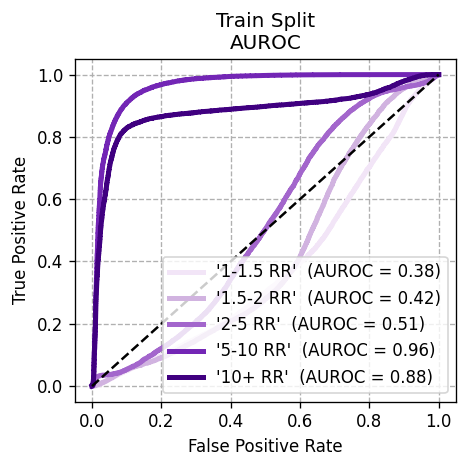

Nº of positive disease pairs: 476619
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 215960
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 86775
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 228223
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 139543
Nº of positive disease pairs: 20000


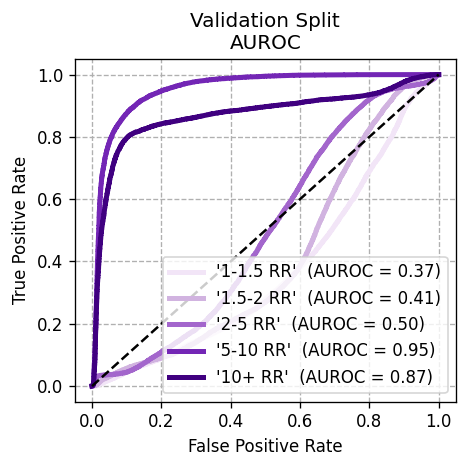

Nº of positive disease pairs: 1129332
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 646962
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 364129
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 152850
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 90450
Nº of positive disease pairs: 20000


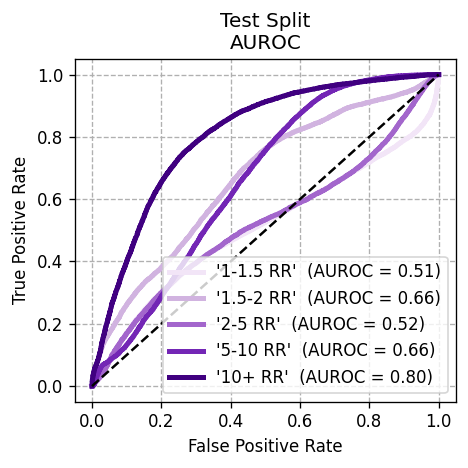

In [15]:
# plot ROC AUC
vz.plot_roc(tr_s_all[:-2], np.array(tr_s_unr), labels=tr_l_all[:-2], title="Train Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=n_samples,dpi=dpi)
vz.plot_roc(vl_s_all[:-2], np.array(vl_s_unr), labels=vl_l_all[:-2], title="Validation Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=n_samples,dpi=dpi)
vz.plot_roc(ts_s_all[:-2], np.array(ts_s_unr), labels=ts_l_all[:-2], title="Test Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=n_samples,dpi=dpi)



In [16]:
# y_1 = list(tr_s_all[3]) + list(tr_s_unr)
# y_2 = [1]*len(tr_s_all[3]) + [0]*len(tr_s_unr)

# average_precision_score(y_score=y_1, y_true=y_2)
# # roc_auc_score(y_score=y_1, y_true=y_2)

In [17]:
# compute ROC-AUC table
_df_tr = get_auroc_df(  "train", 
                        tr_s_all[:-2], 
                        tr_s_unr,
                        ndigits=3
                      )

_df_vl = get_auroc_df("valid",
                      vl_s_all[:-2],
                      vl_s_unr,
                      ndigits=3)

_df_ts = get_auroc_df("test",
                      ts_s_all[:-2],
                      ts_s_unr,
                      ndigits=3)

df_auroc_c = pd.concat([_df_tr, _df_vl, _df_ts])
df_auroc_c

Nº of positive disease pairs: 2170988
Nº of positive disease pairs: 977878
Nº of positive disease pairs: 392037
Nº of positive disease pairs: 1013726
Nº of positive disease pairs: 476619
Nº of positive disease pairs: 215960
Nº of positive disease pairs: 86775
Nº of positive disease pairs: 228223
Nº of positive disease pairs: 1129332
Nº of positive disease pairs: 646962
Nº of positive disease pairs: 364129
Nº of positive disease pairs: 152850


,Split,1-1.5 RR,1.5-2 RR,2-5 RR,+10 RR
0,train,0.379,0.415,0.513,0.961
0,valid,0.371,0.404,0.496,0.951
0,test,0.505,0.665,0.518,0.657


In [ ]:
# perform for entire space


## 2.2 Benchmark Ontology Unrelated but Comorbid Diseases

In [18]:
# get all comorbidities which are NOT ontology similar
_df_com_100_q = _df_com_100.query("lin <=0.396")


# bin data based on similarity
_df_com_100_q = _df_com_100_q.copy()
_df_com_100_q["shortest_path_length"] = get_bins(_df_com_100_q["RR"].values)


_bin_labels = ["'1-1.5 RR'","'1.5-2 RR'","'2-5 RR'","'5-10 RR'","'10+ RR'"]

# train
tr_s_all_unr, tr_w_all_unr, tr_l_all_unr = vz.get_related_dis_sim(
    adata_train, c_matrix_train, _df_com_100_q, df_unrelated, labels=_bin_labels, sample=n_samples,
)


100%|██████████| 18969/18969 [00:11<00:00, 1720.95it/s]


Nº of unrelated disease pairs: 324141892
[SP '1-1.5 RR'] Nº of related disease pairs: 60


100%|██████████| 60/60 [00:02<00:00, 26.45it/s]


Nº of related disease pairs for '1-1.5 RR': 1965596
[SP '1.5-2 RR'] Nº of related disease pairs: 18


100%|██████████| 18/18 [00:01<00:00, 17.13it/s]


...

Nº of related disease pairs for '5-10 RR': 0
[SP '10+ RR'] Nº of related disease pairs: 0


0it [00:00, ?it/s]


Nº of related disease pairs for '10+ RR': 0
Nº of diseases: 208


100%|██████████| 208/208 [00:09<00:00, 20.80it/s]


Nº of unrelated disease pairs: 1965596


In [19]:

# valid
vl_s_all_unr, vl_w_all_unr, vl_l_all_unr = vz.get_related_dis_sim_splits(
     adata_valid, adata_train, c_matrix_valid_vs_train, _df_com_100_q, df_unrelated, labels=_bin_labels, sample=n_samples)

# test
ts_s_all_unr, ts_w_all_unr, ts_l_all_unr = vz.get_related_dis_sim_splits(
     adata_test, adata_train, c_matrix_test_vs_train, _df_com_100_q, df_unrelated, labels=_bin_labels, sample=n_samples)

100%|██████████| 18969/18969 [01:37<00:00, 194.60it/s]


Nº of unrelated disease pairs: 72037096
[SP '1-1.5 RR'] Nº of related disease pairs: 60


100%|██████████| 60/60 [00:00<00:00, 110.29it/s]


Nº of related disease pairs for '1-1.5 RR': 431089
[SP '1.5-2 RR'] Nº of related disease pairs: 18


100%|██████████| 18/18 [00:00<00:00, 72.65it/s]


...

Nº of related disease pairs for '5-10 RR': 0
Nothing for '5-10 RR'
[SP '10+ RR'] Nº of related disease pairs: 0


0it [00:00, ?it/s]


Nº of related disease pairs for '10+ RR': 0
Nothing for '10+ RR'
Nº of diseases: 206


100%|██████████| 206/206 [00:01<00:00, 106.89it/s]


Nº of unrelated disease pairs: 1100378


AttributeError: 'numpy.ndarray' object has no attribute 'lower'

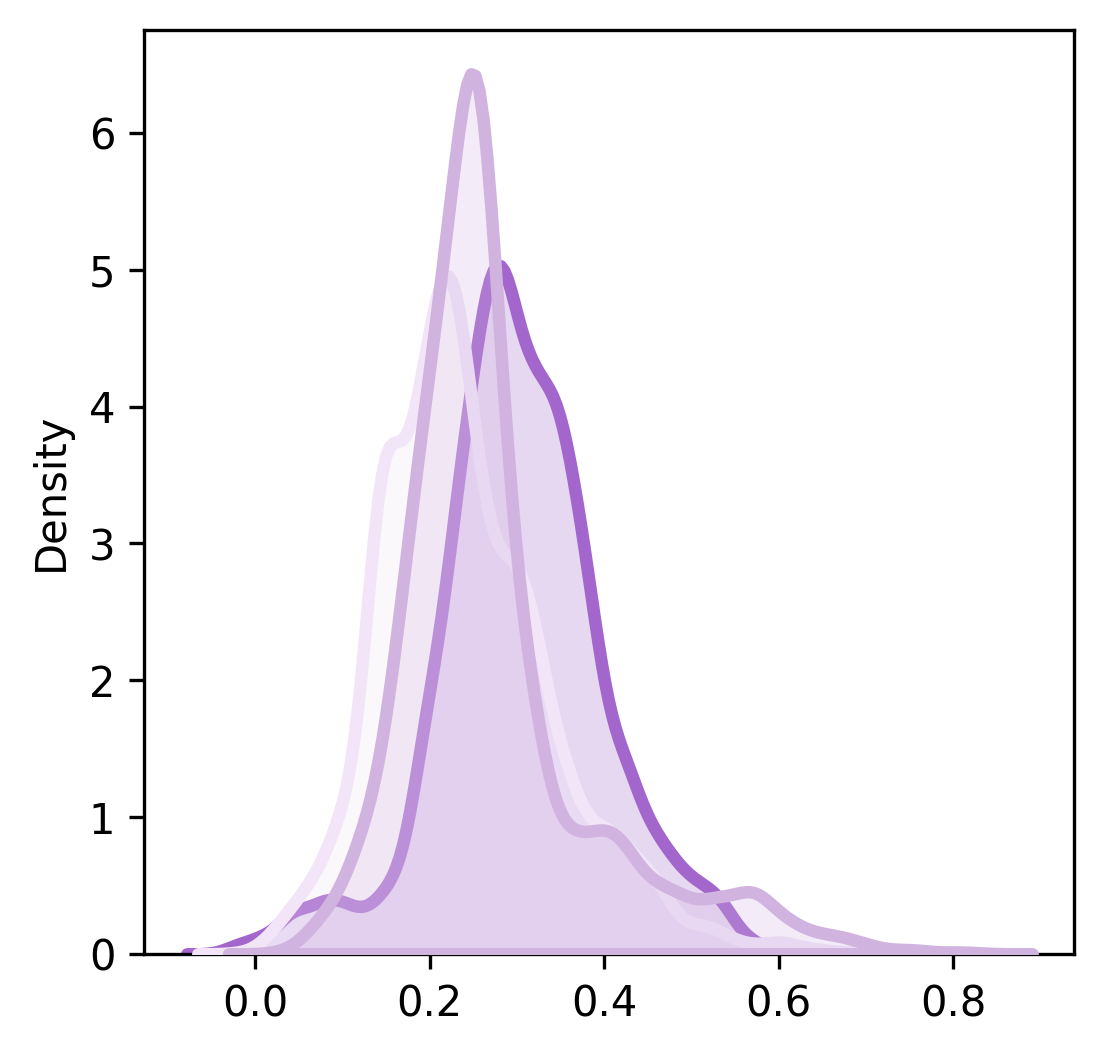

In [ ]:
purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]
dpi=300

vz.plot_kde(tr_s_all_unr[:-2] + [tr_s_unr], 
            labels=tr_l_all_unr[:-2] + [tr_l_all_unr[-1]]   ,
            title="Train Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = n_samples,   
            metric="Cosine Similarity",
            dpi=dpi)

vz.plot_kde(vl_s_all_unr[:-2] + [vl_s_unr], 
            labels=vl_l_all_unr[:-2] + [vl_l_all_unr[-1]]   ,
            title="Validation Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = n_samples,   
            metric="Cosine Similarity",
            dpi=dpi)

vz.plot_kde(ts_s_all_unr[:-2] + [ts_s_unr], 
            labels=ts_l_all_unr[:-2] + [ts_l_all_unr[-1]]   ,
            title="Test Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = n_samples,   
            metric="Cosine Similarity",
            dpi=dpi)

Nº of positive disease pairs: 1965596
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 904512
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 363662
Nº of positive disease pairs: 20000


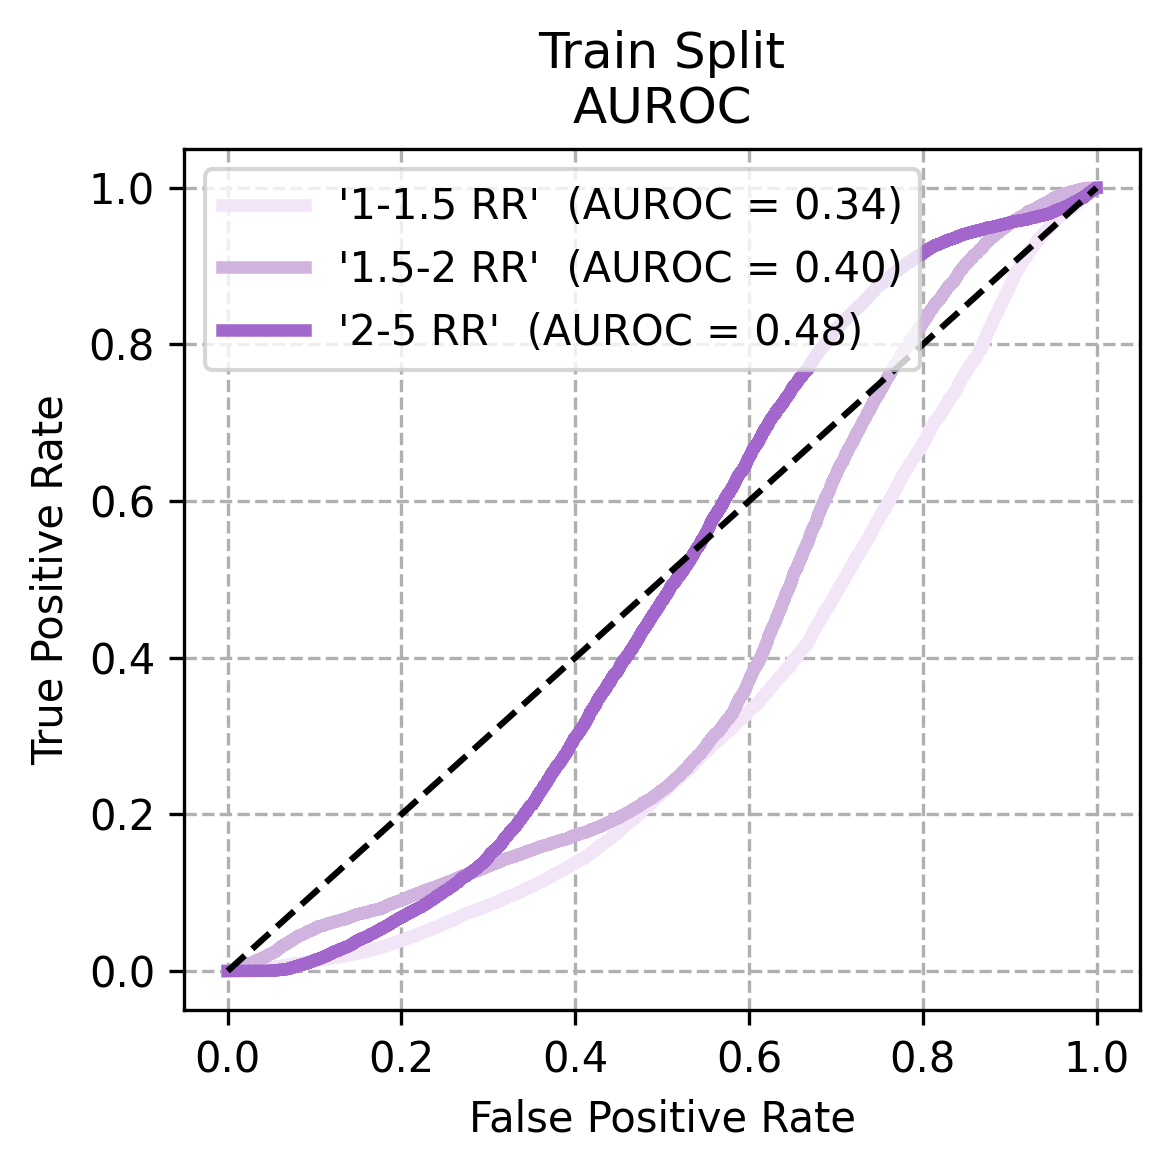

Nº of positive disease pairs: 431089
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 199738
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 80934
Nº of positive disease pairs: 20000


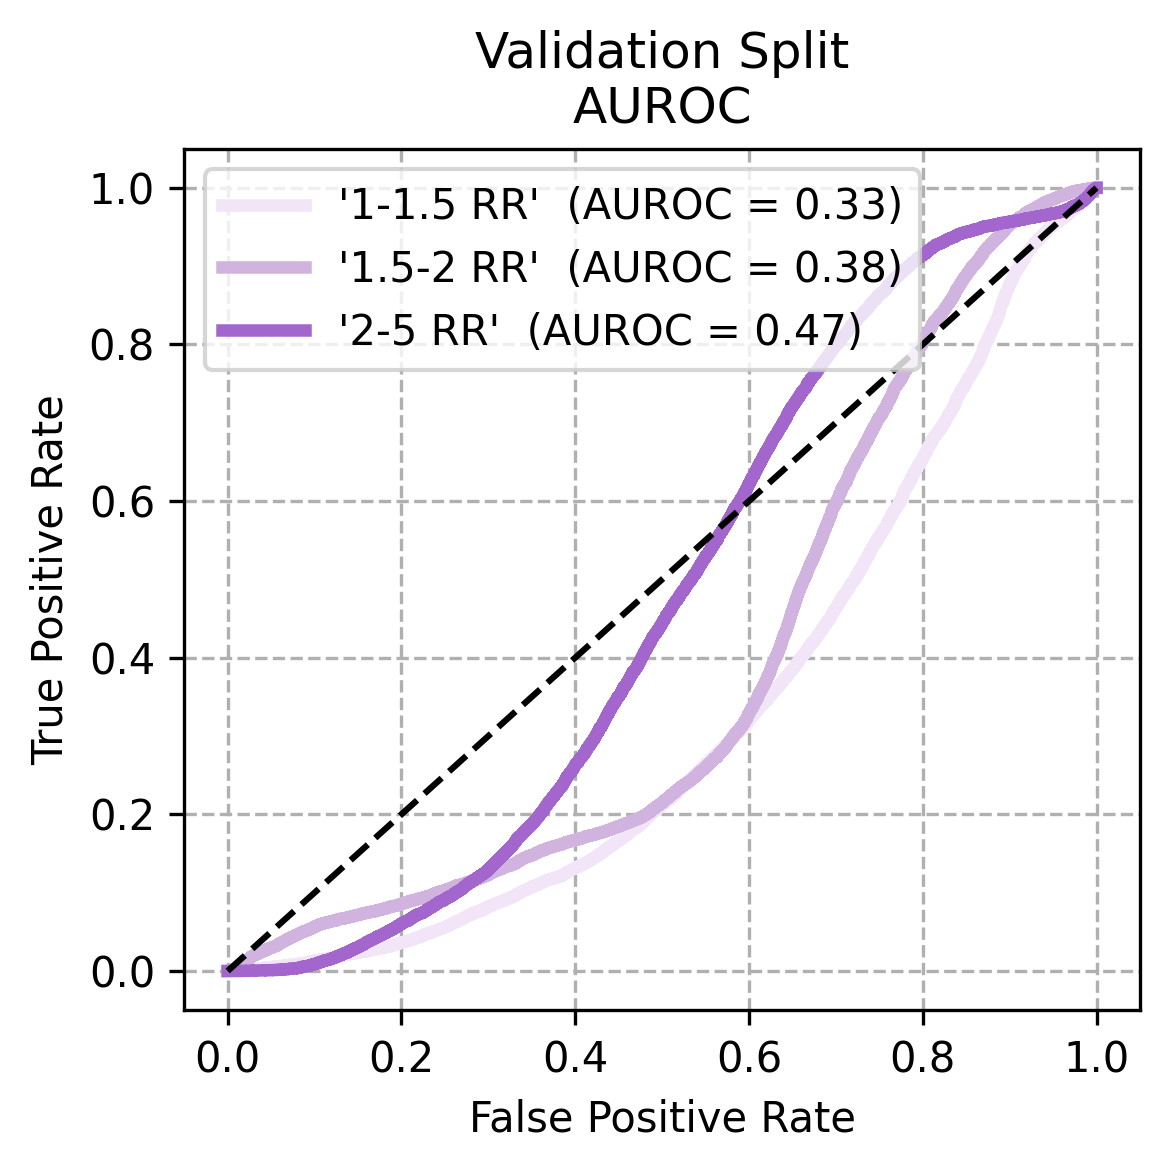

Nº of positive disease pairs: 1100378
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 467458
Nº of positive disease pairs: 20000
Nº of positive disease pairs: 272990
Nº of positive disease pairs: 20000


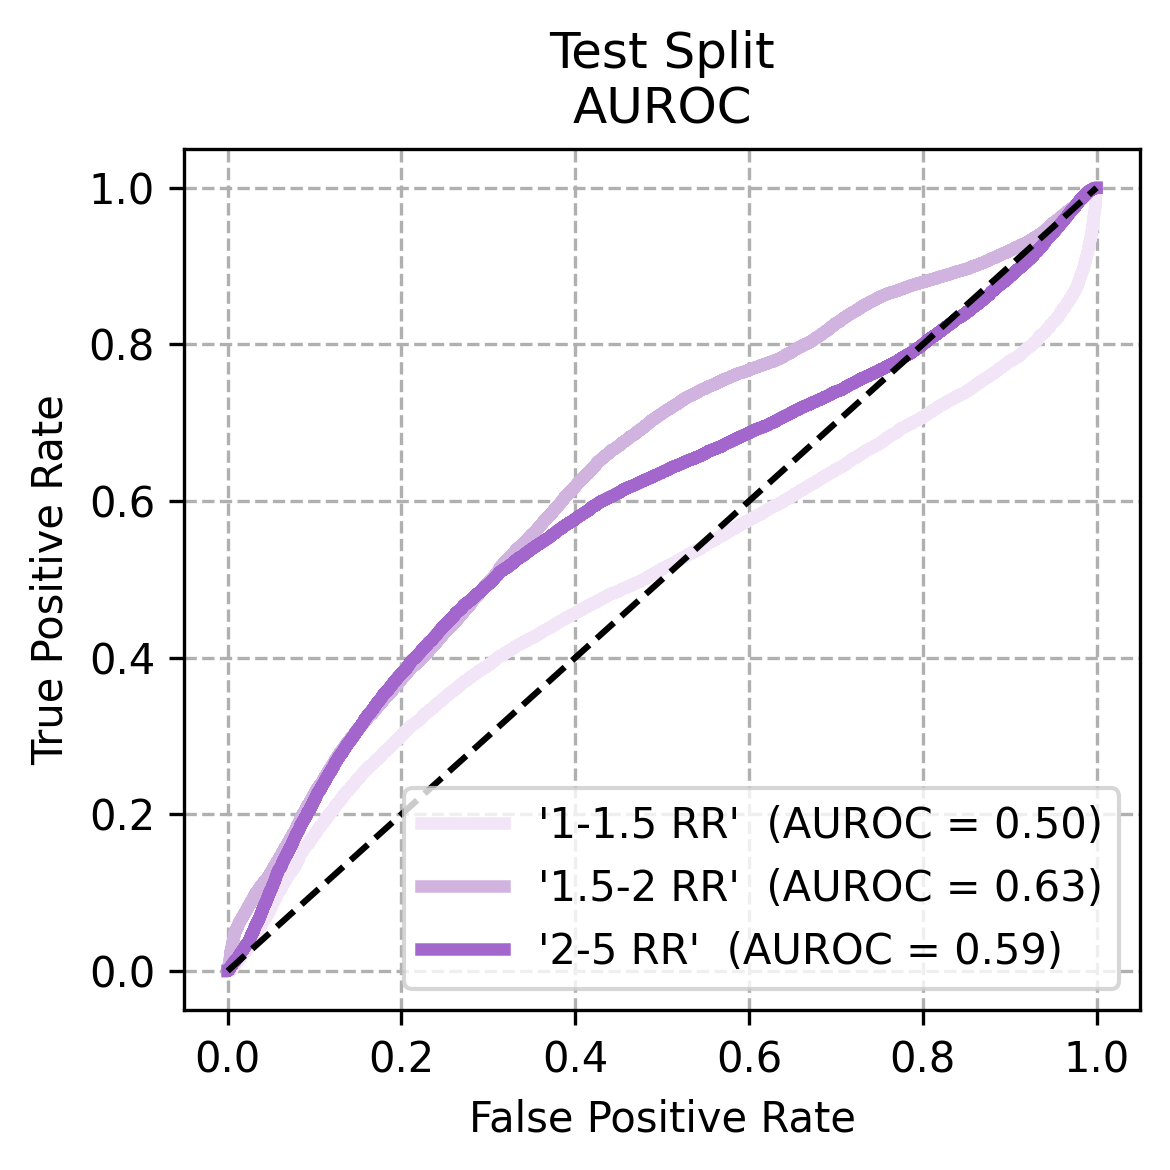

In [31]:
# plot ROC AUC
vz.plot_roc(tr_s_all_unr[:-2], np.array(tr_s_unr), labels=tr_l_all_unr[:-2], title="Train Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=n_samples,dpi=dpi)
vz.plot_roc(vl_s_all_unr[:-2], np.array(vl_s_unr), labels=vl_l_all_unr[:-2], title="Validation Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=n_samples,dpi=dpi)
vz.plot_roc(ts_s_all_unr[:-2], np.array(ts_s_unr), labels=ts_l_all_unr[:-2], title="Test Split\nAUROC", colors=purple_scale+["grey"], w_pos=None,sample=n_samples,dpi=dpi)


In [22]:
# compute ROC-AUC table
_df_tr = get_auroc_df(  "train", 
                        tr_s_all_unr[:-2], 
                        tr_s_unr,
                        ndigits=3
                      )

_df_vl = get_auroc_df("valid",
                      vl_s_all_unr[:-2],
                      vl_s_unr,
                      ndigits=3)

_df_ts = get_auroc_df("test",
                      ts_s_all_unr[:-2],
                      ts_s_unr,
                      ndigits=3)

df_auroc_c_unr = pd.concat([_df_tr, _df_vl, _df_ts])
df_auroc_c_unr

Nº of positive disease pairs: 1965596


Nº of positive disease pairs: 904512
Nº of positive disease pairs: 363662


IndexError: list index out of range

## Embedding Similarity vs RR Score

In [ ]:
# Map diseases -> Relative Risk
rr_map = dict()
for _, r in df_com.iterrows():
    d1 = r["doid_1"]
    d2 = r["doid_2"]
    rr = r["RR"]
    if d1 not in rr_map.keys():
        rr_map[d1] = dict()
    if d2 not in rr_map.keys():
        rr_map[d2] = dict()
    rr_map[d1][d2] = rr
    rr_map[d2][d1] = rr



In [ ]:
from tqdm import tqdm
rr_matrix_train = list()

for d1 in tqdm(df_train["doid_id"].to_list()):
    _s_row = list()
    for d2 in df_train["doid_id"].to_list():
        if (d1 == d2):
            _s_row.append(1)
        elif (d1 == "Control") & (d2 != "Control"):
            _s_row.append(0)
        elif (d1 != "Control") & (d2 == "Control"):
            _s_row.append(0)
        else:
            if (d1 in rr_map.keys()) and (d2 in rr_map[d1].keys()):
                _s_row.append(rr_map[d1][d2])
            else:
                _s_row.append(np.nan)
    rr_matrix_train.append(_s_row)
    
rr_matrix_train = np.array(rr_matrix_train)
print(rr_matrix_train.shape)

100%|██████████| 18305/18305 [00:43<00:00, 416.88it/s]


(18305, 18305)


In [ ]:
# get ctrl & dis idxs
_idx_ctrl = np.argwhere(df_train["doid_id"].to_numpy() == "Control" ).flatten()
_idx_dis = np.argwhere(df_train["doid_id"].to_numpy() != "Control").flatten()
_idxs_all = np.array(list(range(len(df_train))))

# get idx pairs
_dts = df_train["dataset"].to_numpy()
pairs = np.array(list(itertools.permutations(_idx_dis, 2)))
pairs_all = np.array(list(itertools.permutations(_idxs_all, 2)))
pairs_dts_diff = np.array([p for p in pairs if _dts[p[0]] != _dts[p[1]]])
print(f"Nº of all pairs universe: {len(pairs_all)}\t Nº of pairs dis {len(pairs)}\nNº of pairs dis diff. datasets {len(pairs_dts_diff)}")


Nº of all pairs universe: 335054720	 Nº of pairs dis 139771506
Nº of pairs dis diff. datasets 137346860


In [ ]:
# filter out from idx pairs those which are nan values (ie. no comorbidity RR score)
def get_valid_idx_pairs(idx_pairs:np.array, m:np.array)->np.array:
    # get idxs which are non-nan values
    _mask = ~np.isnan(m[idx_pairs[:,0], idx_pairs[:,1]])
    idx_pairs = idx_pairs[_mask]
    return idx_pairs

pairs = get_valid_idx_pairs(pairs, rr_matrix_train)
pairs_all = get_valid_idx_pairs(pairs_all, rr_matrix_train)
pairs_dts_diff = get_valid_idx_pairs(pairs_dts_diff, rr_matrix_train)
print(f"Nº of all pairs universe: {len(pairs_all)}\t Nº of pairs dis {len(pairs)}\nNº of pairs dis diff. datasets {len(pairs_dts_diff)}")


Nº of all pairs universe: 209728624	 Nº of pairs dis 14445410
Nº of pairs dis diff. datasets 12056220


/tmp/ipykernel_33496/1167614501.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


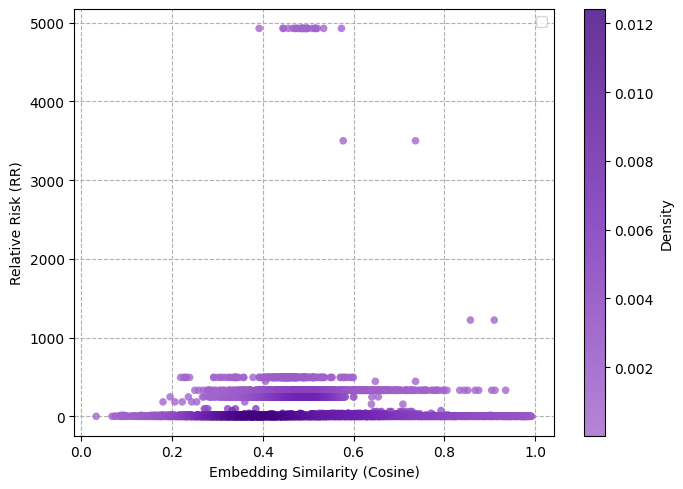

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr
import random
from matplotlib.colors import LinearSegmentedColormap, LogNorm

_mask = rr_matrix_train[pairs_dts_diff[:, 0], pairs_dts_diff[:, 1]] >= 5
_high_idxs =  pairs_dts_diff[_mask]
_mask = rr_matrix_train[pairs_dts_diff[:, 0], pairs_dts_diff[:, 1]] <= 5
_low_idxs = pairs_dts_diff[_mask]

_rnd_idxs = random.sample(list(_low_idxs), 5000)
_rnd_idxs += random.sample(list(_high_idxs), 5000)
_rnd_idxs = np.array(_rnd_idxs)

# _rnd_idxs = np.array(random.sample(list(pairs_dts_diff), 10000))

# _rnd_idxs = pairs_dts_diff
x = c_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]
y = rr_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]

# --- density (KDE)
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)   # density for each point

# sort so dense points are plotted last (on top)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.figure(figsize=(7, 5))
cmap_custom = LinearSegmentedColormap.from_list(
    "ABC_gradient",
    ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"][2:],
    N=256
)

sc = plt.scatter(x, y, c=z, s=30, alpha=0.8, cmap=cmap_custom, edgecolors="none", zorder=3)
plt.colorbar(sc, label="Density")

# --- correlation + regression line
r, p = pearsonr(x, y)
# m, b = np.polyfit(x, y, 1)

# xx = np.linspace(x.min(), x.max(), 200)
# plt.plot(xx, m * xx + b, linewidth=2, label=f"Pearson r={r:.3f} (p={p:.2e})")

plt.grid(linestyle="--", zorder=-3)
plt.xlabel("Embedding Similarity (Cosine)")
plt.ylabel("Relative Risk (RR)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df_com

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
141542,030,428.0,2,2343516,1,2.781935,0.20662424488693,37.4552459363983,0.00032667643131433,0.500093951541559,DOID:1024,DOID:6000,leprosy,congestive heart failure,"(DOID:1024, DOID:6000)"
141556,030,564.1,2,68078,1,95.765284,7.11276381321136,1289.37074936821,0.00268880635527155,0.701549162774235,DOID:1024,DOID:9778,leprosy,irritable bowel syndrome,"(DOID:1024, DOID:9778)"
624179,135,154.1,6908,43013,11,0.482709,0.220409106339276,1.05716184546206,-0.00068517032797409,-0.142098148439253,DOID:11335,DOID:1993,sarcoidosis,rectum cancer,"(DOID:11335, DOID:1993)"
624238,135,183.0,6908,27393,12,0.826864,0.39036641594227,1.75144281350818,-0.000182898283583849,-0.0302700808586769,DOID:11335,DOID:2394,sarcoidosis,ovarian cancer,"(DOID:11335, DOID:2394)"
624347,135,203.0,6908,7923,9,2.144102,0.9012745077071,5.10074639866493,0.000649513006733088,0.0578066697926136,DOID:11335,DOID:9538,sarcoidosis,multiple myeloma,"(DOID:11335, DOID:9538)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.9486709219018,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"
5399494,710.2,720.0,6892,6375,32,9.496628,5.99735352551419,15.0376218924225,0.00432150903489894,0.358714631731391,DOID:12894,DOID:7147,Sjogren's syndrome,ankylosing spondylitis,"(DOID:12894, DOID:7147)"
5423569,714.0,720.0,175906,6375,1506,17.510922,16.3762914745442,18.7241654278765,0.0427034018104937,17.9265483791382,DOID:7148,DOID:7147,rheumatoid arthritis,ankylosing spondylitis,"(DOID:7147, DOID:7148)"
5424127,714.0,758.7,175906,149,4,1.989931,0.54231954720795,7.30164393965983,0.000391331918484729,0.164128183490042,DOID:7148,DOID:1921,rheumatoid arthritis,Klinefelter syndrome,"(DOID:1921, DOID:7148)"


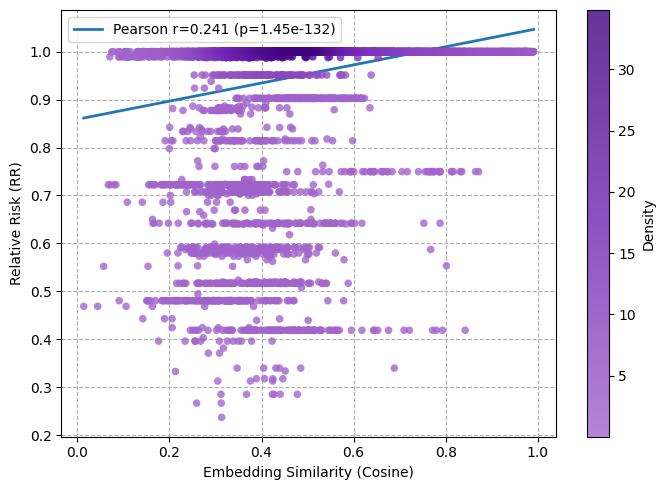

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr
import random
from matplotlib.colors import LinearSegmentedColormap, LogNorm

_mask = rr_matrix_train[pairs_dts_diff[:, 0], pairs_dts_diff[:, 1]] >= 5
_high_idxs =  pairs_dts_diff[_mask]
_mask = rr_matrix_train[pairs_dts_diff[:, 0], pairs_dts_diff[:, 1]] <= 5
_low_idxs = pairs_dts_diff[_mask]

_rnd_idxs = random.sample(list(_low_idxs), 5000)
_rnd_idxs += random.sample(list(_high_idxs), 5000)
_rnd_idxs = np.array(_rnd_idxs)

# _rnd_idxs = np.array(random.sample(list(pairs_dts_diff), 10000))

# _rnd_idxs = pairs_dts_diff
x = c_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]
y = rr_matrix_train[_rnd_idxs[:, 0], _rnd_idxs[:, 1]]
y = np.array([1 if y_i > 1 else y_i for y_i in y])

# --- density (KDE)
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)   # density for each point

# sort so dense points are plotted last (on top)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.figure(figsize=(7, 5))
cmap_custom = LinearSegmentedColormap.from_list(
    "ABC_gradient",
    ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"][2:],
    N=256
)

sc = plt.scatter(x, y, c=z, s=30, alpha=0.8, cmap=cmap_custom, edgecolors="none", zorder=3)
plt.colorbar(sc, label="Density")

# --- correlation + regression line
r, p = pearsonr(x, y)
m, b = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, m * xx + b, linewidth=2, label=f"Pearson r={r:.3f} (p={p:.2e})")

plt.grid(linestyle="--", zorder=-3)
plt.xlabel("Embedding Similarity (Cosine)")
plt.ylabel("Relative Risk (RR)")
plt.legend()
plt.tight_layout()
plt.show()

## Ontology Similarity vs Relative Risk Score

Text(0.5, 1.0, '113 Comorbidity Pairs\nDisease Similarity (Lin) vs\nRelative Risk (RR)')

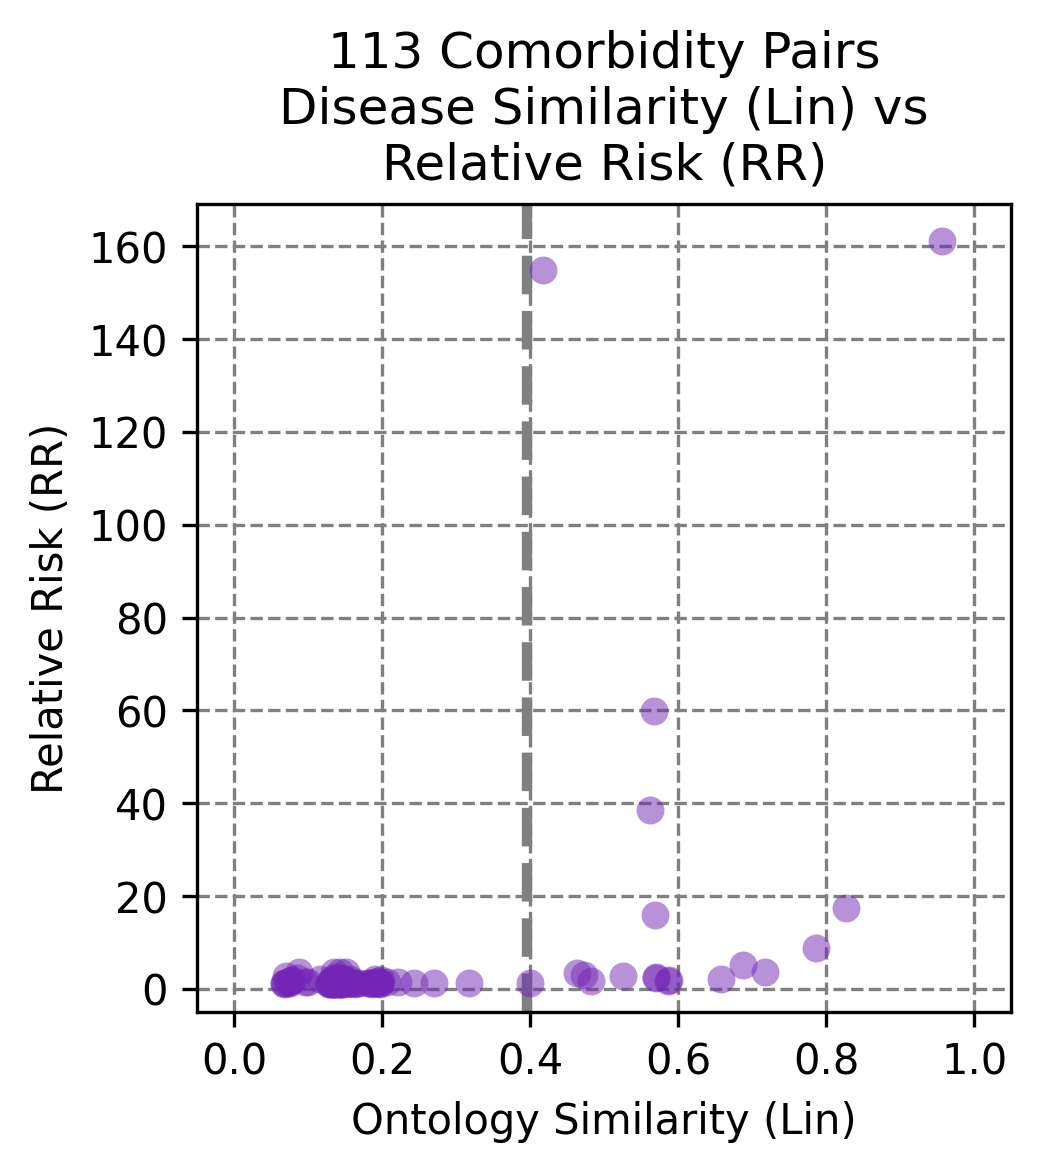

In [ ]:
_df_q = _df_com_100.query("RR >=1")

plt.figure(figsize=(3.5,3.5),dpi=300)
plt.scatter(_df_q["lin"],_df_q["RR"], color="#7326b5", s=45, alpha=0.5, linewidths=0, zorder = 3
            )
plt.axvline(0.396, linestyle="--", color="grey", linewidth=2.5)
plt.xlim(-0.05,1.05)
plt.ylim(-5,)
plt.grid(linestyle="--", color="grey", zorder=-3)
plt.ylabel("Relative Risk (RR)")
plt.xlabel("Ontology Similarity (Lin)")
plt.title(f"{_df_q.shape[0]} Comorbidity Pairs\nDisease Similarity (Lin) vs\nRelative Risk (RR)")b

Text(0.5, 1.0, '113 Comorbidity Pairs\nDisease Similarity (Lin) vs\nRelative Risk (RR)')

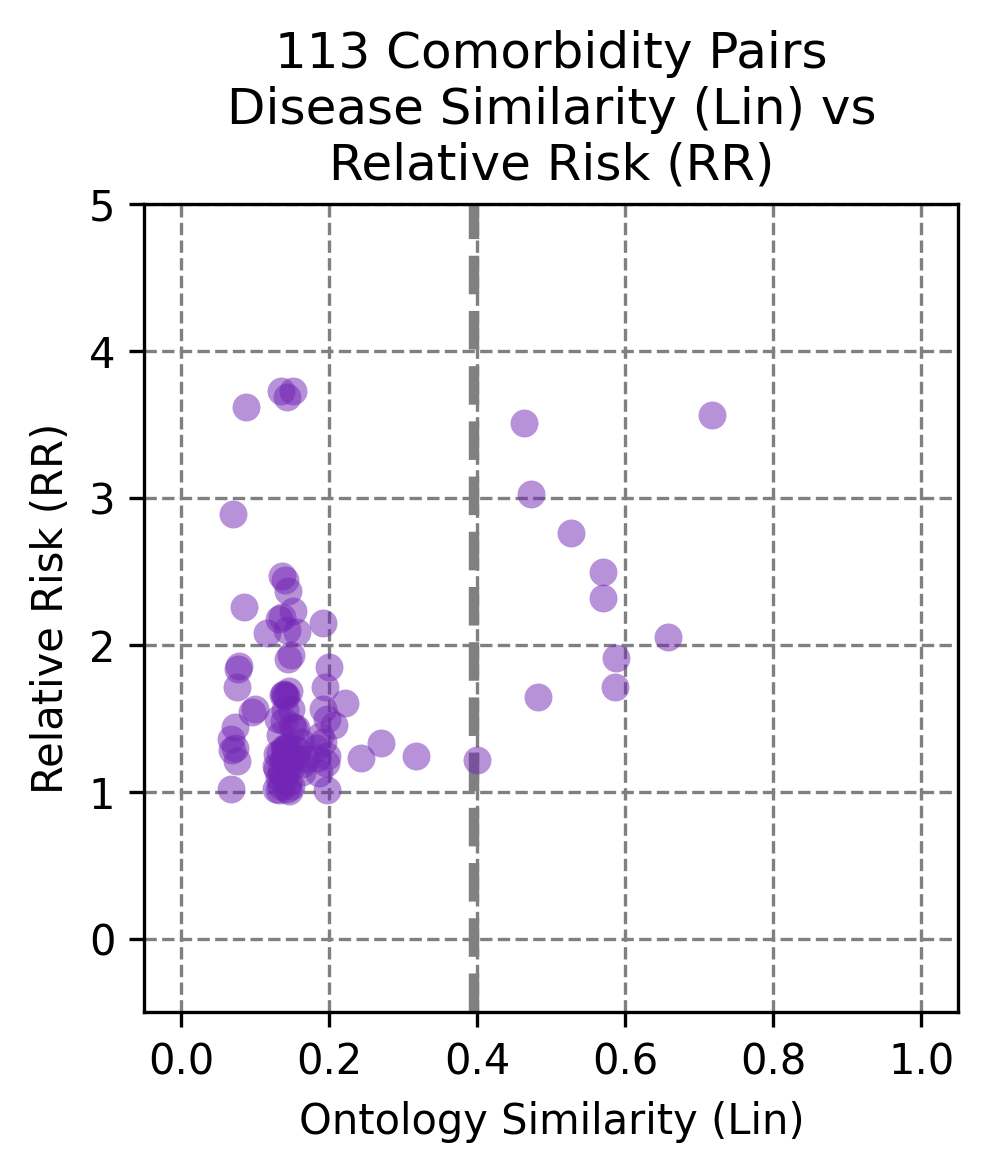

In [29]:
_df_q = _df_com_100.query("RR >=1")

plt.figure(figsize=(3.5,3.5),dpi=300)
plt.scatter(_df_q["lin"],_df_q["RR"], color="#7326b5", s=45, alpha=0.5, linewidths=0, zorder = 3
            )
plt.axvline(0.396, linestyle="--", color="grey", linewidth=2.5)
plt.xlim(-0.05,1.05)
plt.ylim(-0.5,5)
plt.grid(linestyle="--", color="grey", zorder=-3)
plt.ylabel("Relative Risk (RR)")
plt.xlabel("Ontology Similarity (Lin)")
plt.title(f"{_df_q.shape[0]} Comorbidity Pairs\nDisease Similarity (Lin) vs\nRelative Risk (RR)")


In [24]:
_df_com_100

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted,lin,shortest_path_length
475009,088.81,427.31,2642,1806969,372,1.016025,0.887894704133947,1.16264506727048,9.15011373918915e-05,0.122999,DOID:11729,DOID:0060224,Lyme disease,atrial fibrillation,"(DOID:0060224, DOID:11729)",0.066661,1-1.5 RR
475020,088.81,428.0,2642,2343516,352,0.741288,0.645362466322465,0.851471116735574,-0.00172400439094342,-2.639203,DOID:11729,DOID:6000,Lyme disease,congestive heart failure,"(DOID:11729, DOID:6000)",0.072359,0
625287,135,427.31,6908,1806969,918,0.958925,0.880073892645815,1.04484034176344,-0.000379310354957529,-0.509882,DOID:11335,DOID:0060224,sarcoidosis,atrial fibrillation,"(DOID:0060224, DOID:11335)",0.141662,0
625298,135,428.0,6908,2343516,1598,1.287068,1.20602987919301,1.37355087049508,0.00309375967585099,4.736117,DOID:11335,DOID:6000,sarcoidosis,congestive heart failure,"(DOID:11335, DOID:6000)",0.154508,1-1.5 RR
625305,135,429.2,6908,384087,161,0.791205,0.644613208045375,0.971132409325019,-0.000837480219861335,-0.519025,DOID:11335,DOID:1287,sarcoidosis,cardiovascular system disease,"(DOID:11335, DOID:1287)",0.206333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396799,710.0,710.2,21900,6892,446,38.529233,34.0662686145735,43.5768820865929,0.0353996787383209,5.241720,DOID:9074,DOID:12894,systemic lupus erythematosus,Sjogren's syndrome,"(DOID:12894, DOID:9074)",0.561896,10+ RR
5396848,710.0,714.0,21900,175906,1552,5.253054,4.91759648253813,5.61139419034205,0.0204001234539712,8.557778,DOID:9074,DOID:7148,systemic lupus erythematosus,rheumatoid arthritis,"(DOID:7148, DOID:9074)",0.687535,5-10 RR
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.948671,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)",0.568226,10+ RR
5423569,714.0,720.0,175906,6375,1506,17.510922,16.3762914745442,18.7241654278765,0.0427034018104937,17.926548,DOID:7148,DOID:7147,rheumatoid arthritis,ankylosing spondylitis,"(DOID:7147, DOID:7148)",0.826254,10+ RR


Text(0.5, 1.0, 'Unrelated Diseases\nDisease Similarity (Lin) vs\nRelative Risk (RR)')

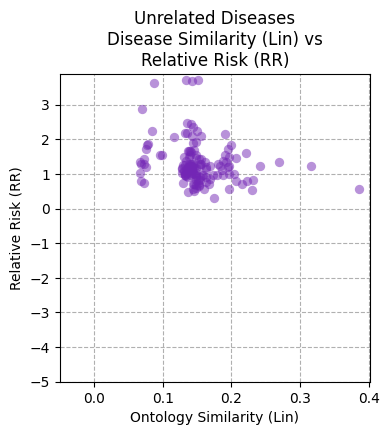

In [25]:
plt.figure(figsize=(4,4))
_df_q = _df_com_100.query("lin < 0.396")
plt.scatter(_df_q["lin"],_df_q["RR"], color="#7326b5", s=45, alpha=0.5, linewidths=0, zorder=3
            )
plt.xlim(-0.05,)
plt.ylim(-5,)
plt.ylabel("Relative Risk (RR)")
plt.xlabel("Ontology Similarity (Lin)")
plt.grid(linestyle="--",zorder=-3)
plt.title(f"Unrelated Diseases\nDisease Similarity (Lin) vs\nRelative Risk (RR)")

In [26]:
# _df_com = pd.read_csv(com_tsv_path, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
# _df_com["n.common"] = _df_com["n.common"].astype(float)
# _df_com[_df_com["n.common"] > 100]

# _df_com["RR"] = _df_com["RR"].astype(float) 
# _df_com["RR.low"] = _df_com["RR.low"].astype(float) 
# _df_com["RR.high"] = _df_com["RR.high"].astype(float) 

In [27]:
import random
import tqdm
from scanpy import AnnData as Anndata

def get_comorb_per_dis(adata_qry:Anndata, adata_ref:Anndata, df_related:pd.DataFrame, df_unrelated:pd.DataFrame, c_matrix:np.ndarray, doid_to_term:dict)->pd.DataFrame:
    results_per_dis = list()
    for doid_i in tqdm(adata_qry.obs["doid_id"].unique()):
        if doid_i == "Control":
            continue
        # get related & unrelated diseases
        related_i = set(df_related.query(f"do1 == '{doid_i}'")["do2"].values)
        related_i = related_i.union(set(df_related.query(f"do2 == '{doid_i}'")["do1"].values))
        related_i = list(related_i)

        unrelated_i = set(df_unrelated.query(f"do1 == '{doid_i}'")["do2"].values)
        unrelated_i = unrelated_i.union(set(df_unrelated.query(f"do2 == '{doid_i}'")["do1"].values))
        unrelated_i = list(unrelated_i)

        # get idxs
        idx_1 = np.array(adata_qry.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # query disease
        idx_2 = np.array(adata_ref.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # reference disease
        idx_3 = np.array(adata_ref.obs.query(f"(doid_id in @related_i)").index).astype(int)  # reference unrelated diseases
        idx_4 = np.array(adata_ref.obs.query(f"(doid_id in @unrelated_i)").index).astype(int)  # reference unrelated diseases
        dsaids = adata_ref.obs.query(f"(doid_id in @unrelated_i)")["dsaid"].unique()
        idx_5 = np.array(adata_ref.obs.query(f"(dsaid in @dsaids)").index).astype(int)  # reference unrelated diseases

        if len(idx_1) == 0 or len(idx_2) == 0 or len(idx_5) == 0:
            print(f"Skipping {doid_i} - {doid_to_term.get(doid_i)} due to lack of pairs")
            print(f"Nº same: {len(idx_2)}\tNº unrelated: {len(idx_5)}")
            continue
        
        idx_pairs_1 = np.array(list(itertools.product(idx_1, idx_2)))
        idx_pairs_2 = np.array(list(itertools.product(idx_1, idx_5)))

        _s_same = c_matrix[idx_pairs_1[:, 0], idx_pairs_1[:, 1]]
        _s_unrelated = c_matrix[idx_pairs_2[:, 0], idx_pairs_2[:, 1]]        

        # results per disease
        ap_i = average_precision_score(
            [1] * len(_s_same) + [0] * (len(_s_unrelated)),
            np.concatenate([_s_same, _s_unrelated])
        )
        random_i = len(_s_same) / (len(_s_same) + len(_s_unrelated)) if (len(_s_same) + len(_s_unrelated)) > 0 else 0
        auroc_i = roc_auc_score(
            [1] * len(_s_same) + [0] * (len(_s_same)),
            np.concatenate([_s_same, np.array(random.sample(list(_s_unrelated), len(_s_same)))])
        )
        
        results_per_dis.append({
            "average_precision": ap_i,
            "roc_auc": auroc_i,
            "random": random_i,
            "disease": doid_to_term.get(doid_i),
            "doid": doid_i,
            "n_positives": len(_s_same),
            "n_unrelated": len(_s_unrelated),
        })

        df_per_dis = pd.DataFrame(results_per_dis)

    return df_per_dis

In [ ]:
# imports 
from matplotlib.ticker import EngFormatter
import random
import importlib
importlib.reload(vz)

# variables
_bin_labels = ["'1-1.5 RR'","'1.5-2 RR'","'2-5 RR'","'5-10 RR'","'10+ RR'"]
n_samples = 20000
purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]


# functions
def get_bins(vals):
    labels = []
    for v in vals:
        if 1 <= v < 1.5:
            lab = "1-1.5 RR"
        elif 1.5 <= v < 2:
            lab = "1.5-2 RR"
        elif 2 <= v < 5:
            lab = "2-5 RR"
        elif 5 <= v < 10:
            lab = "5-10 RR"
        elif v >= 10:
            lab = "10+ RR"
        else:
            lab = 0  # or None, depending on what you prefer
        labels.append(lab)
    return labels


def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    pos = np.array(pos)
    neg = np.array(neg)
    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc


def get_auroc_df(split_name:str, s_comorbid:List, s_unr:np.array, ndigits:int=3) -> pd.DataFrame:
    return pd.DataFrame({
        "Split": [split_name],
        "1-1.5 RR": [round(_auroc(s_comorbid[0], s_unr),ndigits=ndigits)],
        "1.5-2 RR": [round(_auroc(s_comorbid[1], s_unr),ndigits=ndigits)],
        "2-5 RR ": [round(_auroc(s_comorbid[2], s_unr),ndigits=ndigits)],
        "+10 RR" : [round(_auroc(s_comorbid[3], s_unr),ndigits=ndigits)],
    })


# define related and unrelated dataframes
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# get similarity of unrelated diseases
ts_s_unr =vz.get_unrelated_pairs_split(df_test, df_train, df_related, c_matrix_test_vs_train, n_samples=n_samples, use_ctrl=True, exclude_dts=False)
vl_s_unr = vz.get_unrelated_pairs_split(df_valid, df_train, df_related, c_matrix_valid_vs_train, n_samples=n_samples, use_ctrl=True, exclude_dts=False)
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=n_samples,
    seed=42,
)

# bin data based on similarity
_df_com_100 = _df_com_100.copy()
_df_com_100["shortest_path_length"] = get_bins(_df_com_100["RR"].values)


# concatenate all data - compute c_matrix_all
adata_all = adata_train.concatenate(adata_valid, adata_test)

# embeddings all
e_all = np.concatenate([embeddings_train, embeddings_valid, embeddings_test], axis=0)

# compute c_matrix_all
c_matrix_all = vz.get_c_matrix(adata_all, e_all)

# all
tr_s_all, tr_w_all, tr_l_all = vz.get_related_dis_sim(
    adata_all, c_matrix_all, _df_com_100, df_unrelated, labels=_bin_labels, sample=n_samples,
)


NameError: name 'adata_all' is not defined